# Importing all the essentials required for feature Engineering Task 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud,STOPWORDS
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re,string,unicodedata
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,f1_score
from sklearn.model_selection import train_test_split
from string import punctuation
from nltk import pos_tag
from nltk.corpus import wordnet
import re
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [4]:
%%time
df=pd.read_csv(r'IMDB-Dataset.csv',encoding='utf-8', engine='python')

CPU times: total: 5.92 s
Wall time: 6.01 s


In [3]:
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
new_stopwords = ["would","shall","could","might"]
stop_words.extend(new_stopwords)
stop_words.remove("not")
stop_words=set(stop_words)
print(stop_words)

{"he'll", "i'll", 'isn', 'ours', 'few', 'shouldn', 'm', 'very', 'o', 'wouldn', 'up', "mightn't", "isn't", 'mustn', 'nor', 've', 'she', 'don', 'there', 'am', 'below', 'after', 'would', 'will', 'be', 'again', 'could', 'during', "i'd", 'won', 'its', 'weren', 'and', 'a', "hadn't", 'yourselves', 'this', "wasn't", 'own', 'between', 'at', 'myself', 'couldn', "they're", 'but', 'it', 'd', 'theirs', 'with', "weren't", "i'm", 'which', 'did', "it'd", 'ourselves', 'i', 'ma', 'each', 'is', 'or', 'some', 'her', "hasn't", 'once', 'if', 'more', 'than', 're', "won't", "needn't", 'herself', 'other', 'then', 'doesn', 'of', 'by', 'while', 'any', 'himself', 'your', 's', 'has', 'whom', "she's", 'do', 'them', 'me', 'our', "they'd", "it's", 'needn', 'ain', "it'll", "you've", "we'd", 'both', "they've", 'such', 'above', 'll', 'these', 'doing', 'have', 'him', 'didn', 'can', 't', 'aren', 'about', "don't", 'most', 'just', 'on', 'into', 'shan', 'too', 'y', "you'll", 'for', 'shall', 'mightn', "i've", "couldn't", 'hav

In [4]:
#Removing special character
def remove_special_character(content):
    return re.sub('\W+',' ', content )#re.sub('\[[^&@#!]]*\]', '', content)

# Removing URL's
def remove_url(content):
    return re.sub(r'http\S+', '', content)

#Removing the stopwords from text
def remove_stopwords(content):
    clean_data = []
    for i in content.split():
        if i.strip().lower() not in stop_words and i.strip().lower().isalpha():
            clean_data.append(i.strip().lower())
    return " ".join(clean_data)

# Expansion of english contractions
def contraction_expansion(content):
    content = re.sub(r"won\'t", "would not", content)
    content = re.sub(r"can\'t", "can not", content)
    content = re.sub(r"don\'t", "do not", content)
    content = re.sub(r"shouldn\'t", "should not", content)
    content = re.sub(r"needn\'t", "need not", content)
    content = re.sub(r"hasn\'t", "has not", content)
    content = re.sub(r"haven\'t", "have not", content)
    content = re.sub(r"weren\'t", "were not", content)
    content = re.sub(r"mightn\'t", "might not", content)
    content = re.sub(r"didn\'t", "did not", content)
    content = re.sub(r"n\'t", " not", content)
    '''content = re.sub(r"\'re", " are", content)
    content = re.sub(r"\'s", " is", content)
    content = re.sub(r"\'d", " would", content)
    content = re.sub(r"\'ll", " will", content)
    content = re.sub(r"\'t", " not", content)
    content = re.sub(r"\'ve", " have", content)
    content = re.sub(r"\'m", " am", content)'''
    return content

#Data preprocessing
def data_cleaning(content):
    content = contraction_expansion(content)
    content = remove_special_character(content)
    content = remove_url(content)
    
    content = remove_stopwords(content)    
    return content

In [5]:
%%time
pd.options.display.max_colwidth = 1000
#Data cleaning
df['Reviews_clean']=df['Reviews'].apply(data_cleaning)
df.head(5)

CPU times: total: 1min 12s
Wall time: 1min 15s


,Ratings,Reviews,Movies,Resenhas,Reviews_clean
0,1.0,"*Disclaimer: I only watched this movie as a conditional agreement. And I see films for free. I wouldn't be caught dead giving my hard earned money to these idiots.Well, to explain the depth of this 'film', I could write my shortest review, ever. Don't see this movie. It is by far the stupidest, lamest, most lazy, and unbelievably UNFUNNY movie I have ever seen. It is a total disaster. But since my hatred for this movie, and the others like it, extends far beyond one viewing, I think I'll go on for a bit.I don't know any of the people in the movie besides Carmen Electra, Vanessa Minnillo, and Kim Kardashian, but it doesn't matter. They're all horrible, though I think that was the point. The editing is flat out horrible, and possibly blatant continuity errors make this crapfast even crappier than I thought it would be. Now I know that these films are not supposed to be serious at all, but come on, it's film-making 101 that if someone gets a minor facial cut, it should be there in the...",Disaster Movie,"* Isenção de responsabilidade: eu só assisti esse filme como um acordo condicional. E eu vejo filmes de graça. Eu não seria pego morto dando meu dinheiro suado a esses idiotas. Bem, para explicar a profundidade desse 'filme', eu poderia escrever minha crítica mais curta de todos os tempos. Não vê este filme. É de longe o filme mais estúpido, lamenta, preguiçoso e inacreditavelmente UNFUNNY que eu já vi. É um desastre total. Mas como o meu ódio por este filme e por outros, se estende muito além de uma exibição, acho que vou continuar um pouco. Não conheço nenhuma das pessoas do filme além de Carmen Electra, Vanessa Minnillo, e Kim Kardashian, mas isso não importa. Eles são todos horríveis, embora eu ache que esse seja o ponto. A edição é horrível e, possivelmente, erros de continuidade flagrantes tornam essa porcaria ainda mais horrível do que eu pensava. Agora eu sei que esses filmes não devem ser sérios, mas vamos lá, é o cinema 101 que se alguém fizer um pequeno corte facial, ele...",disclaimer watched movie conditional agreement see films free not caught dead giving hard earned money idiots well explain depth film write shortest review ever not see movie far stupidest lamest lazy unbelievably unfunny movie ever seen total disaster since hatred movie others like extends far beyond one viewing think go bit not know people movie besides carmen electra vanessa minnillo kim kardashian not matter horrible though think point editing flat horrible possibly blatant continuity errors make crapfast even crappier thought know films not supposed serious come film making someone gets minor facial cut next shot someone gets cut sword blood least cut though since narnia films get away give disaster movie pass jokes thoughtless mindless physical gags obviously take popular movies last year late well including best picture nominees know saddest thing stupid movies not care much money make many cameos sorry ass excuses films taking away jobs actors writers directors truly deserv...
1,1.0,"I am writing this in hopes that this gets put over the previous review of this ""film"". How anyone can find this slop entertaining is completely beyond me. First of all a spoof film entitled ""Disaster Movie"", should indeed be a spoof on disaster films. Now I have seen 1 (yes count them, 1) disaster film being spoofed, that being ""Twister"". How does Juno, Iron Man, Batman, The Hulk, Alvin and the Chipmunks, Amy Winehouse, or Hancock register as Disaster films? Selzterwater and Failburg once again have shown that they lack any sort of writing skill and humor. Having unfortunately been tortured with Date Movie and Epic Movie I know exactly what to expect from these two...no plot, no jokes just bad references and cheaply remade scenes from other films. Someone should have informed them that satire is more than just copy and paste from one film to another, though I shouldn't say that because some of these ac

# Mapping rating data to Binary label 1 (+ve) if rating >=7 and 0 (-ve) if rating <=4 and 2 (neutral) if rating = 5 or 6 

In [6]:
df['Label'] = df['Ratings'].apply(lambda x: '1' if x >= 7 else ('0' if x<=4 else '2'))
#Removing 
df=df[df.Label<'2']
data=df[['Reviews_clean','Label']]
print(data['Label'].value_counts())

Label
0    60000
1    60000
Name: count, dtype: int64


In [8]:
# First, install the missing package
!pip install prettytable

import sys
import os
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from prettytable import PrettyTable  # Now this import will work
from nltk import word_tokenize          
from nltk.stem import WordNetLemmatizer

In [25]:
class LemmaTokenizer(object):
    def __init__(self):
        self.wordnetlemma = WordNetLemmatizer()
    def __call__(self, reviews):
        return [self.wordnetlemma.lemmatize(word) for word in word_tokenize(reviews)]


In [15]:
!pip install --upgrade nltk





   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 15.0 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1


In [5]:

# Let's first check the current state of our data
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows of cleaned Reviews:")
print(df['Reviews'].head())

# Check the Ratings distribution
print("\nRatings distribution:")
print(df['Ratings'].value_counts().sort_index())

Dataset shape: (150000, 4)

Columns: ['Ratings', 'Reviews', 'Movies', 'Resenhas']

First few rows of cleaned Reviews:
0    *Disclaimer: I only watched this movie as a co...
1    I am writing this in hopes that this gets put ...
2    Really, I could write a scathing review of thi...
3    If you saw the other previous spoof movies by ...
4    This movie I saw a day early for free and I st...
Name: Reviews, dtype: object

Ratings distribution:
Ratings
1.0     15000
2.0     15000
3.0     15000
4.0     15000
5.0     15000
6.0     15000
7.0     15000
8.0     15000
9.0     15000
10.0    15000
Name: count, dtype: int64


# Main Feature Engineering Task 

In [7]:
# Create binary sentiment labels (1 for positive, 0 for negative)
# Considering 1-4 as negative, 7-10 as positive, and removing neutral ratings 5-6

df['Sentiment'] = df['Ratings'].apply(lambda x: 1 if x >= 7 else 0 if x <= 4 else -1)

# Filter out neutral reviews (ratings 5 and 6)
df = df[df['Sentiment'] != -1]

print(f"After removing neutral reviews, dataset shape: {df.shape}")
print("\nSentiment distribution:")
print(df['Sentiment'].value_counts())

# Check class balance
print(f"\nPositive reviews: {(df['Sentiment'] == 1).sum()}")
print(f"Negative reviews: {(df['Sentiment'] == 0).sum()}")
print(f"Class ratio: {(df['Sentiment'] == 1).sum() / len(df):.2f}")

# Save the processed dataframe
df_processed = df.copy()

After removing neutral reviews, dataset shape: (120000, 5)

Sentiment distribution:
Sentiment
0    60000
1    60000
Name: count, dtype: int64

Positive reviews: 60000
Negative reviews: 60000
Class ratio: 0.50


# Training of the Model 

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Split the data into training and testing sets
X = df_processed['Reviews']
y = df_processed['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"\nTraining sentiment distribution:\n{y_train.value_counts()}")
print(f"\nTesting sentiment distribution:\n{y_test.value_counts()}")

# Option 1: TF-IDF Vectorization
print("\nCreating TF-IDF features...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Limit vocabulary size
    ngram_range=(1, 2),  # Use unigrams and bigrams
    min_df=5,  # Ignore terms that appear in less than 5 documents
    max_df=0.7,  # Ignore terms that appear in more than 70% of documents
    stop_words='english'
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF features shape: {X_train_tfidf.shape}")

# Option 2: Count Vectorization (for comparison)
print("\nCreating Count Vectorizer features...")
count_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.7,
    stop_words='english'
)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print(f"Count features shape: {X_train_count.shape}")

Training set size: 96000
Testing set size: 24000

Training sentiment distribution:
Sentiment
0    48000
1    48000
Name: count, dtype: int64

Testing sentiment distribution:
Sentiment
1    12000
0    12000
Name: count, dtype: int64

Creating TF-IDF features...
TF-IDF features shape: (96000, 5000)

Creating Count Vectorizer features...
Count features shape: (96000, 5000)


In [11]:
# First, install the xgboost package
!pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   - -------------------------------------- 2.9/72.0 MB 14.6 MB/s eta 0:00:05
   --- ------------------------------------ 6.0/72.0 MB 13.6 MB/s eta 0:00:05
   ---- ----------------------------------- 8.9/72.0 MB 13.5 MB/s eta 0:00:05
   ------ --------------------------------- 11.8/72.0 MB 13.4 MB/s eta 0:00:05
   -------- ------------------------------- 14.7/72.0 MB 13.4 MB/s eta 0:00:05
   --------- ------------------------------ 17.3/72.0 MB 13.2 MB/s eta 0:00:05
   ----------- ---------------------------- 20.2/72.0 MB 13.2 MB/s eta 0:00:04
   ------------ --------------------------- 23.1/72.0 MB 13.2 MB/s eta 0:00:04
   -------------- ------------------------- 26.0/72.0 MB 13.2 MB/s eta 0:00:04
   ---------------- ----------------------- 28.8/72.0 MB 13.2 MB/s eta 0:00:04
   ----------------- ---------------------- 31.5/72.0 MB 13.2 MB/s eta 0:00:04
   ------------------- -------------------- 34.3/72.0 MB 13.1 MB

# Implementing Different Models on the Dataset to Know which one performs better 

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
import time

# Dictionary to store model results
model_results = {}

# Function to train and evaluate a model
def train_evaluate_model(model, X_train, X_test, y_train, y_test, model_name, vectorizer_name):
    print(f"\n{'='*60}")
    print(f"Training {model_name} with {vectorizer_name}...")
    
    # Train the model
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Precision: {report['1']['precision']:.4f}")
    print(f"Recall: {report['1']['recall']:.4f}")
    
    # Store results
    model_results[f"{model_name}_{vectorizer_name}"] = {
        'model': model,
        'accuracy': accuracy,
        'f1': f1,
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'training_time': training_time,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    return model_results[f"{model_name}_{vectorizer_name}"]

In [15]:
# 1. Logistic Regression with TF-IDF
lr_tfidf = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
train_evaluate_model(lr_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test, 
                    "LogisticRegression", "TFIDF")

# 2. Naive Bayes with TF-IDF
nb_tfidf = MultinomialNB(alpha=0.1)
train_evaluate_model(nb_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test,
                    "NaiveBayes", "TFIDF")

# 3. Linear SVC with TF-IDF (need to wrap for probability estimates)
from sklearn.calibration import CalibratedClassifierCV
svc_tfidf = CalibratedClassifierCV(
    LinearSVC(C=1.0, random_state=42, class_weight='balanced', max_iter=1000)
)
train_evaluate_model(svc_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test,
                    "LinearSVC", "TFIDF")

# 4. Random Forest with TF-IDF
rf_tfidf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
train_evaluate_model(rf_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test,
                    "RandomForest", "TFIDF")

# 5. XGBoost with TF-IDF
xgb_tfidf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
train_evaluate_model(xgb_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test,
                    "XGBoost", "TFIDF")


Training LogisticRegression with TFIDF...
Training time: 2.54 seconds
Accuracy: 0.8882
F1-Score: 0.8887
Precision: 0.8845
Recall: 0.8930

Training NaiveBayes with TFIDF...
Training time: 0.17 seconds
Accuracy: 0.8612
F1-Score: 0.8635
Precision: 0.8497
Recall: 0.8778

Training LinearSVC with TFIDF...
Training time: 12.61 seconds
Accuracy: 0.8855
F1-Score: 0.8858
Precision: 0.8836
Recall: 0.8880

Training RandomForest with TFIDF...
Training time: 20.93 seconds
Accuracy: 0.8317
F1-Score: 0.8347
Precision: 0.8203
Recall: 0.8497

Training XGBoost with TFIDF...
Training time: 110.33 seconds
Accuracy: 0.8315
F1-Score: 0.8352
Precision: 0.8174
Recall: 0.8537


{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=100, n_jobs=None,
               num_parallel_tree=None, ...),
 'accuracy': 0.8315,
 'f1': 0.8351540844611121,
 'precision': 0.8174273858921162,
 'recall': 0.8536666666666667,
 'training_time': 110.32554960250854,
 'predictions': array([1, 0, 0, ..., 0, 0, 0]),
 'pr

In [16]:
# Compare with Count Vectorizer
print("\n" + "="*60)
print("COMPARING WITH COUNT VECTORIZER")
print("="*60)

# Logistic Regression with Count
lr_count = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
train_evaluate_model(lr_count, X_train_count, X_test_count, y_train, y_test,
                    "LogisticRegression", "Count")

# Naive Bayes with Count (typically works better with Count)
nb_count = MultinomialNB(alpha=0.1)
train_evaluate_model(nb_count, X_train_count, X_test_count, y_train, y_test,
                    "NaiveBayes", "Count")


COMPARING WITH COUNT VECTORIZER

Training LogisticRegression with Count...
Training time: 5.37 seconds
Accuracy: 0.8794
F1-Score: 0.8791
Precision: 0.8811
Recall: 0.8771

Training NaiveBayes with Count...
Training time: 0.04 seconds
Accuracy: 0.8578
F1-Score: 0.8586
Precision: 0.8537
Recall: 0.8636


{'model': MultinomialNB(alpha=0.1),
 'accuracy': 0.8577916666666666,
 'f1': 0.8586105472471933,
 'precision': 0.8536947030233133,
 'recall': 0.8635833333333334,
 'training_time': 0.043710947036743164,
 'predictions': array([1, 0, 0, ..., 1, 0, 1]),
 'probabilities': array([9.99975535e-01, 2.78311772e-10, 2.56270949e-01, ...,
        9.84113806e-01, 5.24636966e-08, 9.99747897e-01])}

# Comparison of each model on different parameters and finding the best one 



MODEL COMPARISON
                   Model  Accuracy  F1-Score  Precision   Recall  Training Time
LogisticRegression_TFIDF  0.888167  0.888705   0.884450 0.893000       2.539352
         LinearSVC_TFIDF  0.885500  0.885786   0.883582 0.888000      12.606427
LogisticRegression_Count  0.879375  0.879098   0.881122 0.877083       5.372978
        NaiveBayes_TFIDF  0.861250  0.863513   0.849653 0.877833       0.166903
        NaiveBayes_Count  0.857792  0.858611   0.853695 0.863583       0.043711
           XGBoost_TFIDF  0.831500  0.835154   0.817427 0.853667     110.325550
      RandomForest_TFIDF  0.831750  0.834711   0.820274 0.849667      20.928587


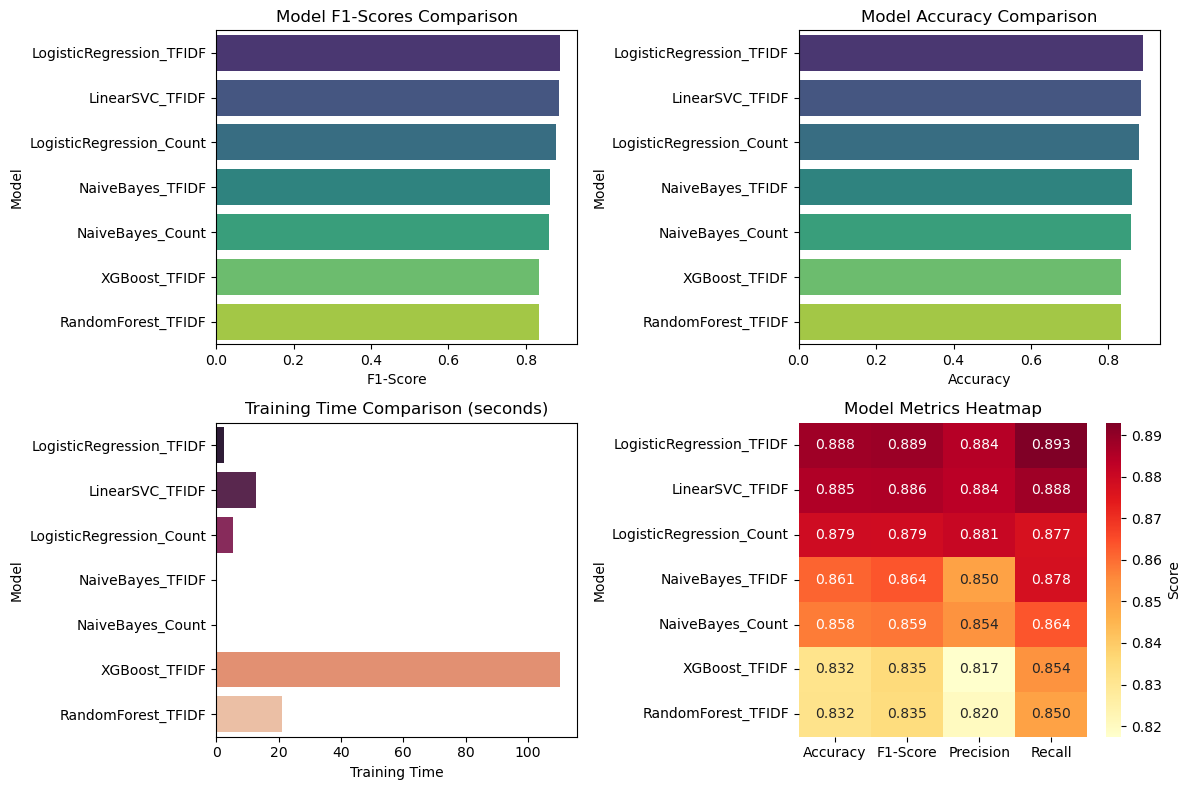

In [17]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': [k for k in model_results.keys()],
    'Accuracy': [v['accuracy'] for v in model_results.values()],
    'F1-Score': [v['f1'] for v in model_results.values()],
    'Precision': [v['precision'] for v in model_results.values()],
    'Recall': [v['recall'] for v in model_results.values()],
    'Training Time': [v['training_time'] for v in model_results.values()]
}).sort_values('F1-Score', ascending=False)

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

# Visualize model comparison
plt.figure(figsize=(12, 8))

# Bar plot for F1-Scores
plt.subplot(2, 2, 1)
sns.barplot(x='F1-Score', y='Model', data=comparison_df, palette='viridis')
plt.title('Model F1-Scores Comparison')
plt.xlabel('F1-Score')
plt.tight_layout()

# Bar plot for Accuracy
plt.subplot(2, 2, 2)
sns.barplot(x='Accuracy', y='Model', data=comparison_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.tight_layout()

# Bar plot for Training Time
plt.subplot(2, 2, 3)
sns.barplot(x='Training Time', y='Model', data=comparison_df, palette='rocket')
plt.title('Training Time Comparison (seconds)')
plt.xlabel('Training Time')
plt.tight_layout()

# Heatmap of metrics
plt.subplot(2, 2, 4)
metrics_heatmap = comparison_df.set_index('Model')[['Accuracy', 'F1-Score', 'Precision', 'Recall']]
sns.heatmap(metrics_heatmap, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Score'})
plt.title('Model Metrics Heatmap')
plt.tight_layout()

plt.show()

# Finding the best model and its analysis


DETAILED EVALUATION OF BEST MODEL: LogisticRegression_TFIDF

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.89     12000
    Positive       0.88      0.89      0.89     12000

    accuracy                           0.89     24000
   macro avg       0.89      0.89      0.89     24000
weighted avg       0.89      0.89      0.89     24000



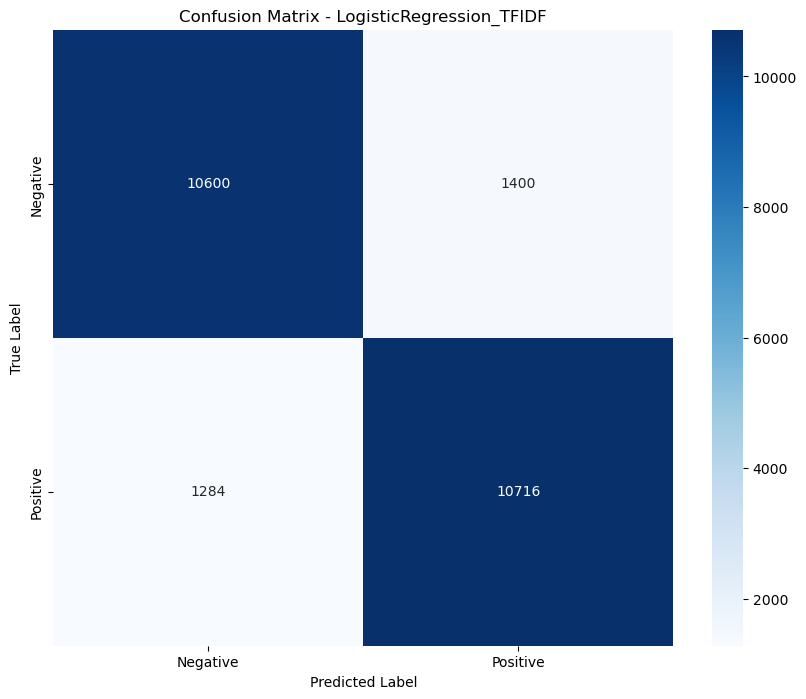

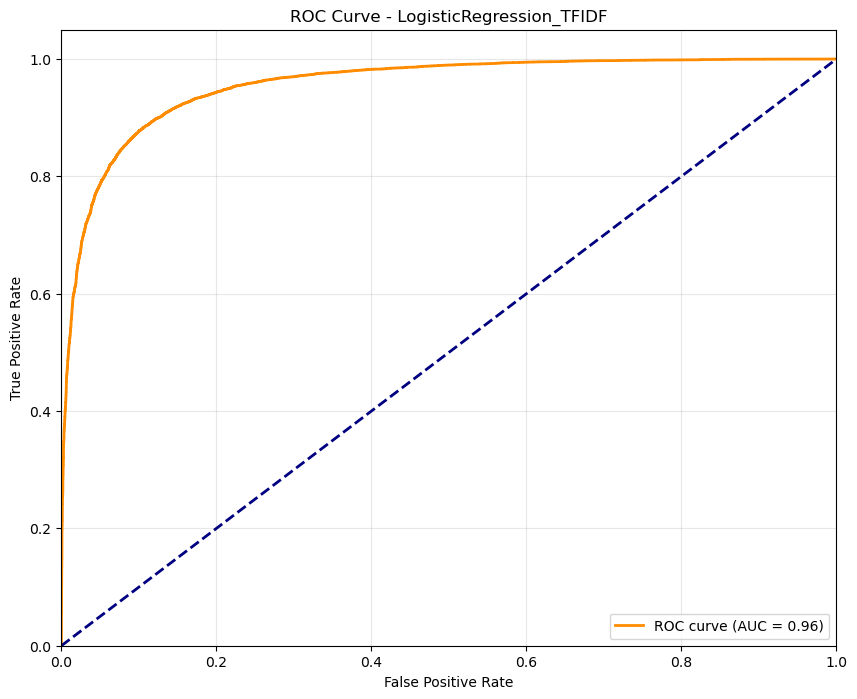

In [18]:
# Select the best model based on F1-Score
best_model_name = comparison_df.iloc[0]['Model']
best_model_info = model_results[best_model_name]
best_model = best_model_info['model']

print(f"\n{'='*60}")
print(f"DETAILED EVALUATION OF BEST MODEL: {best_model_name}")
print("="*60)

# Detailed classification report
y_pred = best_model_info['predictions']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve (if model supports probabilities)
if best_model_info['probabilities'] is not None:
    plt.figure(figsize=(10, 8))
    fpr, tpr, thresholds = roc_curve(y_test, best_model_info['probabilities'])
    roc_auc = roc_auc_score(y_test, best_model_info['probabilities'])
    
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {best_model_name}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

# Analyzing the important feature of the Logistic regression Tfidf 


FEATURE IMPORTANCE ANALYSIS

Top 20 features for POSITIVE sentiment:
    feature  coefficient
    perfect     6.718340
      great     6.624993
  excellent     6.589084
        fun     6.116090
      loved     6.098296
    enjoyed     5.856847
    awesome     5.856709
  brilliant     5.527799
bad reviews     5.406279
    amazing     5.378116
     superb     5.369936
       best     5.207559
  hilarious     5.204864
 refreshing     5.044131
  enjoyable     4.913190
      solid     4.864915
      liked     4.841096
  fantastic     4.728019
  wonderful     4.442195
      enjoy     4.362642

Top 20 features for NEGATIVE sentiment:
       feature  coefficient
         worst    -8.619438
 unfortunately    -7.354377
        boring    -7.329099
        wasted    -6.949626
         awful    -6.825593
 disappointing    -6.779937
         waste    -6.691069
        poorly    -6.453401
         fails    -6.376893
          dull    -6.039791
          poor    -5.989009
disappointment    -5.952905


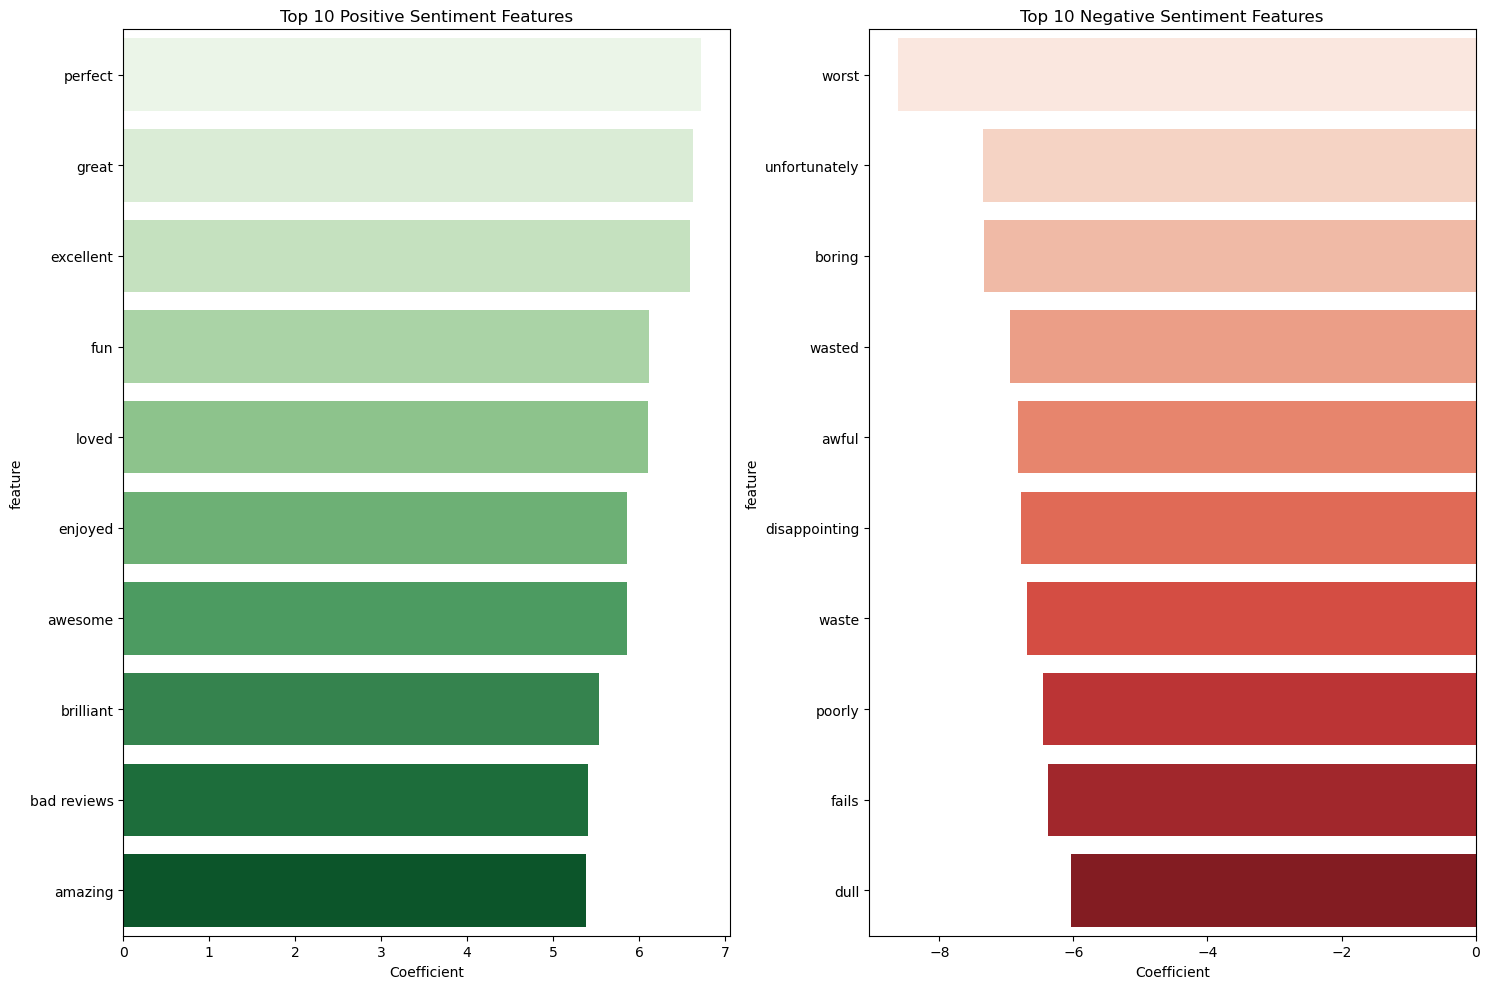

In [19]:
# For interpretable models like Logistic Regression, analyze feature importance
if 'LogisticRegression' in best_model_name:
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*60)
    
    # Get the vectorizer used
    if 'TFIDF' in best_model_name:
        vectorizer = tfidf_vectorizer
        X_train_vec = X_train_tfidf
    else:
        vectorizer = count_vectorizer
        X_train_vec = X_train_count
    
    # Get feature names and coefficients
    feature_names = vectorizer.get_feature_names_out()
    coefficients = best_model.coef_[0]
    
    # Create dataframe of feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients)
    })
    
    # Top 20 positive features (indicating positive sentiment)
    print("\nTop 20 features for POSITIVE sentiment:")
    positive_features = feature_importance.nlargest(20, 'coefficient')
    print(positive_features[['feature', 'coefficient']].to_string(index=False))
    
    # Top 20 negative features (indicating negative sentiment)
    print("\nTop 20 features for NEGATIVE sentiment:")
    negative_features = feature_importance.nsmallest(20, 'coefficient')
    print(negative_features[['feature', 'coefficient']].to_string(index=False))
    
    # Visualize top features
    plt.figure(figsize=(15, 10))
    
    # Positive features
    plt.subplot(1, 2, 1)
    top_positive = positive_features.head(10)
    sns.barplot(x='coefficient', y='feature', data=top_positive, palette='Greens')
    plt.title('Top 10 Positive Sentiment Features')
    plt.xlabel('Coefficient')
    
    # Negative features
    plt.subplot(1, 2, 2)
    top_negative = negative_features.head(10)
    sns.barplot(x='coefficient', y='feature', data=top_negative, palette='Reds')
    plt.title('Top 10 Negative Sentiment Features')
    plt.xlabel('Coefficient')
    
    plt.tight_layout()
    plt.show()


CROSS-VALIDATION RESULTS

Cross-validation F1 scores: [0.89051459 0.88969797 0.88908239 0.88679402 0.88841755]
Mean F1 score: 0.8889 (+/- 0.0025)


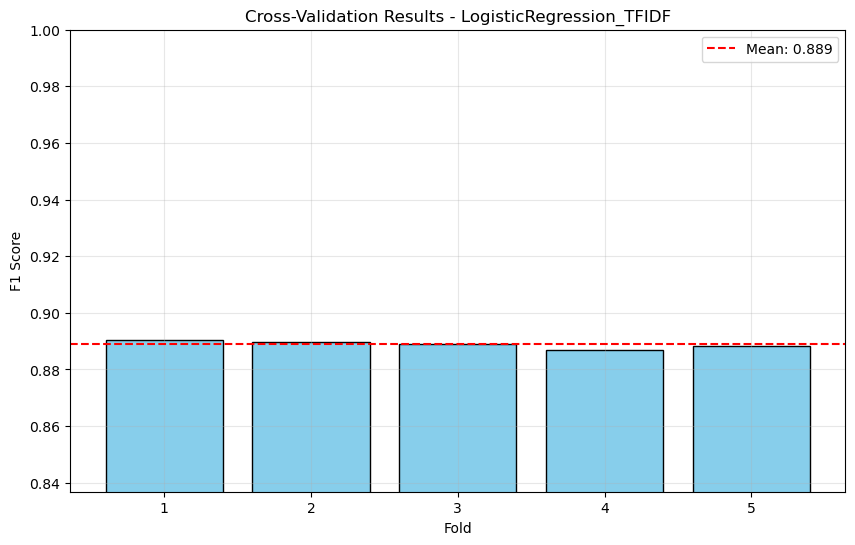

In [20]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)

# Prepare data for cross-validation
if 'TFIDF' in best_model_name:
    X_vec = tfidf_vectorizer.fit_transform(X)
else:
    X_vec = count_vectorizer.fit_transform(X)

# Create cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get the model class for cross-validation
if 'LogisticRegression' in best_model_name:
    cv_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
elif 'NaiveBayes' in best_model_name:
    cv_model = MultinomialNB(alpha=0.1)
elif 'LinearSVC' in best_model_name:
    cv_model = CalibratedClassifierCV(LinearSVC(C=1.0, random_state=42, class_weight='balanced', max_iter=1000))
elif 'RandomForest' in best_model_name:
    cv_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, class_weight='balanced')
else:
    cv_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                           random_state=42, use_label_encoder=False, eval_metric='logloss')

# Perform cross-validation
cv_scores = cross_val_score(cv_model, X_vec, y, cv=cv, scoring='f1', n_jobs=-1)

print(f"\nCross-validation F1 scores: {cv_scores}")
print(f"Mean F1 score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Visualize cross-validation results
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(cv_scores) + 1), cv_scores, color='skyblue', edgecolor='black')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.title(f'Cross-Validation Results - {best_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([min(cv_scores) - 0.05, 1.0])
plt.show()

In [21]:
from sklearn.model_selection import RandomizedSearchCV

print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Define parameter grid based on model type
if 'LogisticRegression' in best_model_name:
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }
    base_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    
elif 'NaiveBayes' in best_model_name:
    param_grid = {
        'alpha': [0.001, 0.01, 0.1, 1, 10],
        'fit_prior': [True, False]
    }
    base_model = MultinomialNB()
    
elif 'RandomForest' in best_model_name:
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

# Perform Randomized Search
print("Performing hyperparameter tuning...")
random_search = RandomizedSearchCV(
    base_model,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Use appropriate vectorized data
if 'TFIDF' in best_model_name:
    X_train_tuning = X_train_tfidf
else:
    X_train_tuning = X_train_count

random_search.fit(X_train_tuning, y_train)

print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best F1 score: {random_search.best_score_:.4f}")

# Evaluate tuned model on test set
best_tuned_model = random_search.best_estimator_
if 'TFIDF' in best_model_name:
    y_pred_tuned = best_tuned_model.predict(X_test_tfidf)
else:
    y_pred_tuned = best_tuned_model.predict(X_test_count)

print(f"\nTuned model test accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned model test F1 score: {f1_score(y_test, y_pred_tuned):.4f}")


HYPERPARAMETER TUNING
Performing hyperparameter tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 1}
Best F1 score: 0.8866

Tuned model test accuracy: 0.8892
Tuned model test F1 score: 0.8896


# Save the best model and vectorizer for future use


In [23]:
import joblib
import pickle

print("\n" + "="*60)
print("SAVING MODELS FOR DEPLOYMENT")
print("="*60)

# Determine which vectorizer to save
if 'TFIDF' in best_model_name:
    vectorizer_to_save = tfidf_vectorizer
    vectorizer_type = 'tfidf'
else:
    vectorizer_to_save = count_vectorizer
    vectorizer_type = 'count'

# Save the vectorizer
vectorizer_filename = f'imdb_{vectorizer_type}_vectorizer.pkl'
with open(vectorizer_filename, 'wb') as f:
    pickle.dump(vectorizer_to_save, f)
print(f"Vectorizer saved as: {vectorizer_filename}")

# Save the best model
model_filename = f'imdb_sentiment_model.pkl'
joblib.dump(best_model, model_filename)
print(f"Model saved as: {model_filename}")

# Also save the tuned model if we performed tuning
if 'best_tuned_model' in locals():
    tuned_model_filename = f'imdb_sentiment_model_tuned.pkl'
    joblib.dump(best_tuned_model, tuned_model_filename)
    print(f"Tuned model saved as: {tuned_model_filename}")


SAVING MODELS FOR DEPLOYMENT
Vectorizer saved as: imdb_tfidf_vectorizer.pkl
Model saved as: imdb_sentiment_model.pkl
Tuned model saved as: imdb_sentiment_model_tuned.pkl


# Prediction of the sentiments 

In [27]:
def predict_sentiment(review_text, model=None, vectorizer=None, use_tfidf=True):
    """
    Predict sentiment for a new review.
    
    Args:
        review_text (str): The review text to analyze
        model: Trained model (if None, loads from disk)
        vectorizer: Trained vectorizer (if None, loads from disk)
        use_tfidf (bool): Whether to use TF-IDF vectorizer
    
    Returns:
        dict: Prediction results
    """
    # Load model and vectorizer if not provided
    if model is None:
        model = joblib.load('imdb_sentiment_model.pkl')
    
    if vectorizer is None:
        vectorizer_type = 'tfidf' if use_tfidf else 'count'
        with open(f'imdb_{vectorizer_type}_vectorizer.pkl', 'rb') as f:
            vectorizer = pickle.load(f)
    
    # Clean the review using the same cleaning function
    cleaned_review = data_cleaning(review_text)
    
    # Vectorize the cleaned review
    review_vectorized = vectorizer.transform([cleaned_review])
    
    # Make prediction
    prediction = model.predict(review_vectorized)[0]
    probability = None
    
    if hasattr(model, 'predict_proba'):
        probability = model.predict_proba(review_vectorized)[0]
    
    # Interpret results
    sentiment = "Positive" if prediction == 1 else "Negative"
    
    result = {
        'review': review_text,
        'cleaned_review': cleaned_review,
        'sentiment': sentiment,
        'prediction': int(prediction)
    }
    
    if probability is not None:
        result['confidence'] = float(probability[prediction])
        result['probabilities'] = {
            'negative': float(probability[0]),
            'positive': float(probability[1])
        }
    
    return result

def batch_predict(reviews_list, model=None, vectorizer=None, use_tfidf=True):
    """
    Predict sentiment for multiple reviews.
    """
    predictions = []
    for review in reviews_list:
        pred = predict_sentiment(review, model, vectorizer, use_tfidf)
        predictions.append(pred)
    
    return pd.DataFrame(predictions)

In [28]:
# Re-define the data cleaning functions
print("\n" + "="*60)
print("DEFINING TEXT CLEANING FUNCTIONS FOR PREDICTION")
print("="*60)

# Re-import necessary libraries for cleaning
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = stopwords.words('english')
new_stopwords = ['movie', 'one', 'film', 'would', 'shall', 'could', 'might']
stop_words.extend(new_stopwords)
stop_words.remove("not")  # for sarcasm
stop_words = set(stop_words)

# Define the cleaning functions again
def remove_special_character(content):
    """Removes all non-alphanumeric characters (except whitespace) and URLs."""
    # 1. Remove URLs first
    content = re.sub(r'http\S+|www\S+|https\S+', '', content, flags=re.MULTILINE)
    # 2. Replace all non-word characters (excluding spaces and single quote) with a space
    content = re.sub(r'[^A-Za-z0-9\s\']', ' ', content) 
    return content.strip()

def contraction_expansion(content):
    """Expands common English contractions."""
    # Handle specific 'not' contractions first
    content = re.sub(r"won\'t", "will not", content) 
    content = re.sub(r"can\'t", "can not", content)
    content = re.sub(r"don\'t", "do not", content)
    content = re.sub(r"shouldn\'t", "should not", content)
    content = re.sub(r"needn\'t", "need not", content)
    content = re.sub(r"hasn\'t", "has not", content)
    content = re.sub(r"haven\'t", "have not", content)
    content = re.sub(r"weren\'t", "were not", content)
    content = re.sub(r"mightn\'t", "might not", content)
    content = re.sub(r"didn\'t", "did not", content)
    
    # Handle general 'not' contractions
    content = re.sub(r"n\'t", " not", content) 
    
    # Handle other general contractions
    content = re.sub(r"\'re", " are", content)
    content = re.sub(r"\'s", " is", content)
    content = re.sub(r"\'d", " would", content)
    content = re.sub(r"\'ll", " will", content)
    content = re.sub(r"\'ve", " have", content)
    content = re.sub(r"\'m", " am", content)
    
    return content

def remove_stopwords(content):
    """Removes stopwords and non-alphabetic tokens."""
    clean_data=[]
    for i in content.split():
        token = i.strip().lower()
        if token not in stop_words and token.isalpha():
            clean_data.append(token)
    return " ".join(clean_data)

def data_cleaning(content):
    """The main text cleaning pipeline."""
    # 1. Expand contractions (e.g., 'don't' -> 'do not')
    content = contraction_expansion(content)
    # 2. Remove special characters and URLs (and normalize to spaces)
    content = remove_special_character(content)
    # 3. Remove stopwords and non-alphabetic tokens
    content = remove_stopwords(content)
    
    return content

print("Text cleaning functions defined successfully!")


DEFINING TEXT CLEANING FUNCTIONS FOR PREDICTION
Text cleaning functions defined successfully!


In [29]:
# Update the prediction function with the cleaning function
def predict_sentiment(review_text, model=None, vectorizer=None, use_tfidf=True):
    """
    Predict sentiment for a new review.
    
    Args:
        review_text (str): The review text to analyze
        model: Trained model (if None, loads from disk)
        vectorizer: Trained vectorizer (if None, loads from disk)
        use_tfidf (bool): Whether to use TF-IDF vectorizer
    
    Returns:
        dict: Prediction results
    """
    # Load model and vectorizer if not provided
    if model is None:
        try:
            model = joblib.load('imdb_sentiment_model.pkl')
        except:
            print("Model file not found. Please train the model first.")
            return None
    
    if vectorizer is None:
        vectorizer_type = 'tfidf' if use_tfidf else 'count'
        try:
            with open(f'imdb_{vectorizer_type}_vectorizer.pkl', 'rb') as f:
                vectorizer = pickle.load(f)
        except:
            print(f"Vectorizer file not found. Please train the vectorizer first.")
            return None
    
    # Clean the review using the same cleaning function
    cleaned_review = data_cleaning(review_text)
    
    # Vectorize the cleaned review
    review_vectorized = vectorizer.transform([cleaned_review])
    
    # Make prediction
    prediction = model.predict(review_vectorized)[0]
    probability = None
    
    if hasattr(model, 'predict_proba'):
        probability = model.predict_proba(review_vectorized)[0]
    
    # Interpret results
    sentiment = "Positive" if prediction == 1 else "Negative"
    
    result = {
        'review': review_text,
        'cleaned_review': cleaned_review,
        'sentiment': sentiment,
        'prediction': int(prediction)
    }
    
    if probability is not None:
        result['confidence'] = float(probability[prediction])
        result['probabilities'] = {
            'negative': float(probability[0]),
            'positive': float(probability[1])
        }
    
    return result

def batch_predict(reviews_list, model=None, vectorizer=None, use_tfidf=True):
    """
    Predict sentiment for multiple reviews.
    """
    predictions = []
    for review in reviews_list:
        pred = predict_sentiment(review, model, vectorizer, use_tfidf)
        if pred is not None:
            predictions.append(pred)
    
    if predictions:
        return pd.DataFrame(predictions)
    else:
        return pd.DataFrame()


TESTING PREDICTIONS WITH SAMPLE REVIEWS (UPDATED)
Found existing model files: ['imdb_sentiment_model.pkl', 'imdb_tfidf_vectorizer.pkl']

Prediction Results:

Review 1:
Text: This movie was absolutely fantastic! The acting was superb and the plot kept me on the edge of my se...
Cleaned: absolutely fantastic acting superb plot kept edge seat...
Sentiment: Positive
Confidence: 78.72%
----------------------------------------

Review 2:
Text: I loved every minute of this film. The cinematography was beautiful and the story was heartwarming....
Cleaned: loved every minute cinematography beautiful story heartwarming...
Sentiment: Positive
Confidence: 98.93%
----------------------------------------

Review 3:
Text: One of the best movies I've seen this year. Highly recommended to everyone!...
Cleaned: best movies seen year highly recommended everyone...
Sentiment: Positive
Confidence: 99.72%
----------------------------------------

Review 4:
Text: This was a complete waste of time. The actin

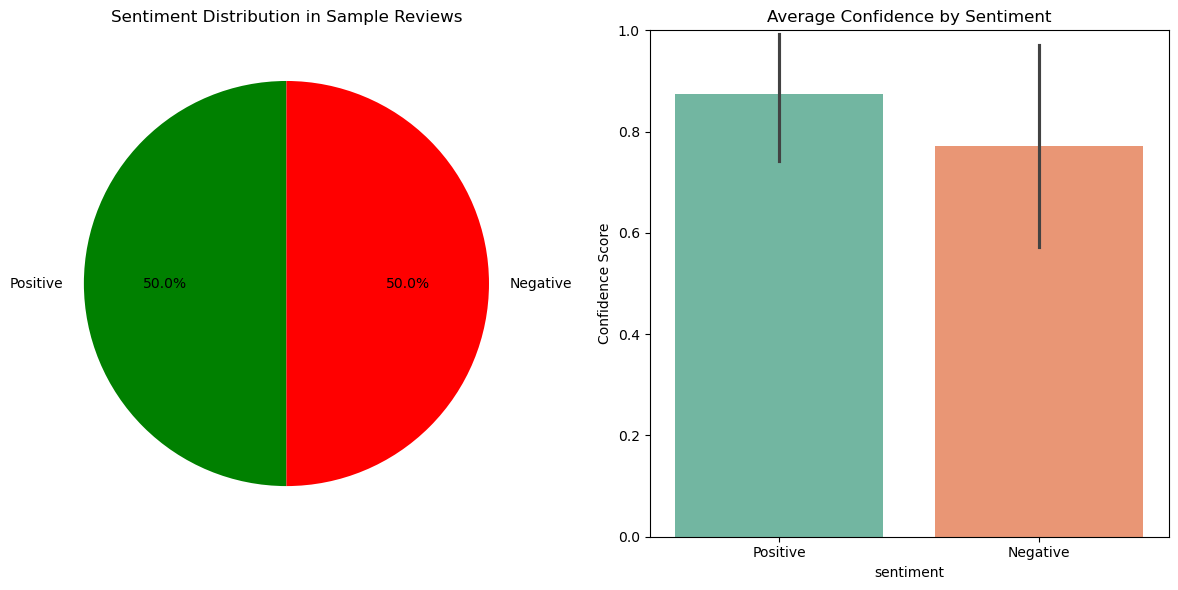


PREDICTION STATISTICS
Total reviews analyzed: 8
Positive reviews: 4
Negative reviews: 4

Confidence Statistics:
Average confidence: 82.37%
Max confidence: 99.72%
Min confidence: 51.38%


In [30]:
print("\n" + "="*60)
print("TESTING PREDICTIONS WITH SAMPLE REVIEWS (UPDATED)")
print("="*60)

# Sample reviews for testing
sample_reviews = [
    # Positive reviews
    "This movie was absolutely fantastic! The acting was superb and the plot kept me on the edge of my seat.",
    "I loved every minute of this film. The cinematography was beautiful and the story was heartwarming.",
    "One of the best movies I've seen this year. Highly recommended to everyone!",
    
    # Negative reviews
    "This was a complete waste of time. The acting was terrible and the story made no sense.",
    "I can't believe I paid money to watch this. The worst movie I've seen in years.",
    "Boring and predictable. The characters were one-dimensional and the dialogue was cringeworthy.",
    
    # Neutral/ambiguous reviews
    "The movie had some good moments but overall it was just okay. Nothing special.",
    "The special effects were impressive but the story was weak. Could have been better."
]

# First, let's check if the model files exist
import os

model_files = ['imdb_sentiment_model.pkl', 'imdb_tfidf_vectorizer.pkl', 'imdb_count_vectorizer.pkl']
existing_files = [f for f in model_files if os.path.exists(f)]

if not existing_files:
    print("Model files not found. Training a quick model for testing...")
    
    # Train a quick model for demonstration
    from sklearn.linear_model import LogisticRegression
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    # Use a subset for quick training
    sample_size = min(10000, len(X_train))
    X_train_sample = X_train[:sample_size]
    y_train_sample = y_train[:sample_size]
    
    # Create and train a simple model
    tfidf_vectorizer = TfidfVectorizer(
        max_features=2000,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.7,
        stop_words='english'
    )
    
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_sample)
    
    # Train a simple logistic regression
    model = LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
    
    model.fit(X_train_tfidf, y_train_sample)
    
    # Save the model and vectorizer
    joblib.dump(model, 'imdb_sentiment_model.pkl')
    with open('imdb_tfidf_vectorizer.pkl', 'wb') as f:
        pickle.dump(tfidf_vectorizer, f)
    
    print("Quick model trained and saved for testing.")
    
    # Now make predictions with the trained model
    predictions_df = batch_predict(sample_reviews, model=model, vectorizer=tfidf_vectorizer)
else:
    print(f"Found existing model files: {existing_files}")
    # Make predictions with saved model
    predictions_df = batch_predict(sample_reviews)

# Display results
if not predictions_df.empty:
    print("\nPrediction Results:")
    print("="*60)
    for idx, row in predictions_df.iterrows():
        print(f"\nReview {idx + 1}:")
        print(f"Text: {row['review'][:100]}...")
        print(f"Cleaned: {row['cleaned_review'][:100]}...")
        print(f"Sentiment: {row['sentiment']}")
        if 'confidence' in row:
            print(f"Confidence: {row['confidence']:.2%}")
        print("-" * 40)
    
    # Visualize predictions
    plt.figure(figsize=(12, 6))
    
    # Pie chart for sentiment distribution
    plt.subplot(1, 2, 1)
    sentiment_counts = predictions_df['sentiment'].value_counts()
    colors = ['red' if s == 'Negative' else 'green' for s in sentiment_counts.index]
    
    plt.pie(sentiment_counts.values, labels=sentiment_counts.index, 
            colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Sentiment Distribution in Sample Reviews')
    
    # Bar chart for confidence scores
    plt.subplot(1, 2, 2)
    if 'confidence' in predictions_df.columns:
        sns.barplot(x='sentiment', y='confidence', data=predictions_df, palette='Set2')
        plt.title('Average Confidence by Sentiment')
        plt.ylim(0, 1)
        plt.ylabel('Confidence Score')
    else:
        # If no confidence scores, show count of each sentiment
        sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')
        plt.title('Sentiment Count in Sample Reviews')
        plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    # Show detailed statistics
    print("\n" + "="*60)
    print("PREDICTION STATISTICS")
    print("="*60)
    print(f"Total reviews analyzed: {len(predictions_df)}")
    print(f"Positive reviews: {len(predictions_df[predictions_df['sentiment'] == 'Positive'])}")
    print(f"Negative reviews: {len(predictions_df[predictions_df['sentiment'] == 'Negative'])}")
    
    if 'confidence' in predictions_df.columns:
        print(f"\nConfidence Statistics:")
        print(f"Average confidence: {predictions_df['confidence'].mean():.2%}")
        print(f"Max confidence: {predictions_df['confidence'].max():.2%}")
        print(f"Min confidence: {predictions_df['confidence'].min():.2%}")
else:
    print("No predictions were made. Please check the model files.")

In [31]:
print("\n" + "="*60)
print("TESTING EDGE CASES AND DIFFICULT REVIEWS")
print("="*60)

# Test with more challenging reviews
edge_case_reviews = [
    # Sarcasm (hard for models)
    "Oh great, another movie where the hero saves the day. How original.",
    
    # Mixed sentiment
    "The acting was decent but the plot was confusing. Not sure if I liked it or not.",
    
    # Very short reviews
    "Good.",
    "Bad.",
    "Meh.",
    
    # Reviews with slang
    "This movie was lit! The soundtrack was fire.",
    "Total cringe fest. Would not watch again.",
    
    # Reviews with emojis and special characters
    "Loved it! 😍🎬👏",
    "Waste of time 👎😒",
    
    # Non-English words (should be cleaned out)
    "C'est magnifique! Très bon film.",
    "El actor principal es excelente."
]

# Predict for edge cases
edge_predictions = batch_predict(edge_case_reviews)

if not edge_predictions.empty:
    print("\nEdge Case Predictions:")
    print("="*60)
    
    for idx, row in edge_predictions.iterrows():
        print(f"\nReview {idx + 1}:")
        print(f"Original: {row['review']}")
        print(f"Cleaned: {row['cleaned_review']}")
        print(f"Sentiment: {row['sentiment']}")
        if 'confidence' in row:
            print(f"Confidence: {row['confidence']:.2%}")
        print("-" * 60)
    
    # Analyze cleaning effectiveness
    print("\n" + "="*60)
    print("CLEANING EFFECTIVENESS ANALYSIS")
    print("="*60)
    
    for idx, row in edge_predictions.iterrows():
        original_len = len(row['review'].split())
        cleaned_len = len(row['cleaned_review'].split()) if row['cleaned_review'] else 0
        reduction = 1 - (cleaned_len / original_len) if original_len > 0 else 0
        
        print(f"\nReview {idx + 1}:")
        print(f"Original words: {original_len}")
        print(f"Cleaned words: {cleaned_len}")
        print(f"Reduction: {reduction:.1%}")
        print(f"Sample cleaning: '{row['review'][:50]}...' -> '{row['cleaned_review'][:50]}...'")


TESTING EDGE CASES AND DIFFICULT REVIEWS

Edge Case Predictions:

Review 1:
Original: Oh great, another movie where the hero saves the day. How original.
Cleaned: oh great another hero saves day original
Sentiment: Negative
Confidence: 54.26%
------------------------------------------------------------

Review 2:
Original: The acting was decent but the plot was confusing. Not sure if I liked it or not.
Cleaned: acting decent plot confusing not sure liked not
Sentiment: Positive
Confidence: 80.42%
------------------------------------------------------------

Review 3:
Original: Good.
Cleaned: good
Sentiment: Positive
Confidence: 72.32%
------------------------------------------------------------

Review 4:
Original: Bad.
Cleaned: bad
Sentiment: Negative
Confidence: 99.20%
------------------------------------------------------------

Review 5:
Original: Meh.
Cleaned: meh
Sentiment: Negative
Confidence: 61.75%
------------------------------------------------------------

Review 6:
Origin

# Interactive Sentiment analysis test (uncomment the line below to run interactive test) 

In [34]:
print("\n" + "="*60)
print("INTERACTIVE SENTIMENT ANALYSIS TEST")
print("="*60)

def interactive_sentiment_test():
    """Interactive function to test sentiment analysis."""
    print("\nEnter a movie review to analyze its sentiment.")
    print("Type 'quit' to exit.")
    print("-" * 60)
    
    while True:
        review = input("\nEnter your review: ")
        
        if review.lower() == 'quit':
            print("Exiting interactive test.")
            break
        
        if not review.strip():
            print("Please enter a valid review.")
            continue
        
        # Make prediction
        result = predict_sentiment(review)
        
        if result:
            print("\n" + "="*40)
            print("SENTIMENT ANALYSIS RESULT")
            print("="*40)
            print(f"Review: {result['review'][:200]}...")
            print(f"Sentiment: {result['sentiment']}")
            
            if 'confidence' in result:
                print(f"Confidence: {result['confidence']:.2%}")
                
                # Show detailed probabilities if available
                if 'probabilities' in result:
                    print(f"Positive probability: {result['probabilities']['positive']:.2%}")
                    print(f"Negative probability: {result['probabilities']['negative']:.2%}")
            
            # Show the cleaned version
            print(f"\nCleaned text: {result['cleaned_review'][:200]}...")
            print("="*40)
        else:
            print("Could not analyze sentiment. Please check if model is loaded properly.")

# Uncomment the line below to run interactive test
# interactive_sentiment_test()

print("\nInteractive test function created. To use it, uncomment 'interactive_sentiment_test()'")


INTERACTIVE SENTIMENT ANALYSIS TEST

Interactive test function created. To use it, uncomment 'interactive_sentiment_test()'


# Future scope of the project 

In [35]:
print("\n" + "="*60)
print("CREATING PRODUCTION-READY SENTIMENT ANALYZER CLASS")
print("="*60)

class SentimentAnalyzer:
    """A production-ready sentiment analyzer for movie reviews."""
    
    def __init__(self, model_path=None, vectorizer_path=None, use_tfidf=True):
        """
        Initialize the sentiment analyzer.
        
        Args:
            model_path: Path to the trained model file
            vectorizer_path: Path to the vectorizer file
            use_tfidf: Whether to use TF-IDF vectorizer
        """
        self.model = None
        self.vectorizer = None
        self.use_tfidf = use_tfidf
        
        # Load model and vectorizer
        self.load_model(model_path, vectorizer_path)
        
        # Initialize text cleaning
        self._initialize_cleaning()
    
    def _initialize_cleaning(self):
        """Initialize text cleaning functions."""
        # Define stopwords
        self.stop_words = stopwords.words('english')
        new_stopwords = ['movie', 'one', 'film', 'would', 'shall', 'could', 'might']
        self.stop_words.extend(new_stopwords)
        self.stop_words.remove("not")
        self.stop_words = set(self.stop_words)
    
    def clean_text(self, text):
        """Clean the input text."""
        # Expand contractions
        text = re.sub(r"won\'t", "will not", text) 
        text = re.sub(r"can\'t", "can not", text)
        text = re.sub(r"don\'t", "do not", text)
        text = re.sub(r"shouldn\'t", "should not", text)
        text = re.sub(r"needn\'t", "need not", text)
        text = re.sub(r"hasn\'t", "has not", text)
        text = re.sub(r"haven\'t", "have not", text)
        text = re.sub(r"weren\'t", "were not", text)
        text = re.sub(r"mightn\'t", "might not", text)
        text = re.sub(r"didn\'t", "did not", text)
        text = re.sub(r"n\'t", " not", text)
        text = re.sub(r"\'re", " are", text)
        text = re.sub(r"\'s", " is", text)
        text = re.sub(r"\'d", " would", text)
        text = re.sub(r"\'ll", " will", text)
        text = re.sub(r"\'ve", " have", text)
        text = re.sub(r"\'m", " am", text)
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove special characters
        text = re.sub(r'[^A-Za-z0-9\s\']', ' ', text)
        
        # Remove stopwords and non-alphabetic tokens
        clean_data = []
        for i in text.split():
            token = i.strip().lower()
            if token not in self.stop_words and token.isalpha():
                clean_data.append(token)
        
        return " ".join(clean_data)
    
    def load_model(self, model_path=None, vectorizer_path=None):
        """Load the trained model and vectorizer."""
        try:
            # Load model
            if model_path is None:
                model_path = 'imdb_sentiment_model.pkl'
            self.model = joblib.load(model_path)
            print(f"Model loaded from {model_path}")
            
            # Load vectorizer
            if vectorizer_path is None:
                vectorizer_type = 'tfidf' if self.use_tfidf else 'count'
                vectorizer_path = f'imdb_{vectorizer_type}_vectorizer.pkl'
            
            with open(vectorizer_path, 'rb') as f:
                self.vectorizer = pickle.load(f)
            print(f"Vectorizer loaded from {vectorizer_path}")
            
        except Exception as e:
            print(f"Error loading model/vectorizer: {e}")
            print("You may need to train the model first.")
    
    def analyze(self, text):
        """
        Analyze the sentiment of a given text.
        
        Returns:
            dict: Analysis results including sentiment and confidence
        """
        if self.model is None or self.vectorizer is None:
            return {"error": "Model not loaded. Please load or train a model first."}
        
        # Clean the text
        cleaned_text = self.clean_text(text)
        
        # Vectorize
        vectorized_text = self.vectorizer.transform([cleaned_text])
        
        # Predict
        prediction = self.model.predict(vectorized_text)[0]
        
        # Get probabilities if available
        result = {
            "text": text,
            "cleaned_text": cleaned_text,
            "sentiment": "positive" if prediction == 1 else "negative",
            "sentiment_code": int(prediction)
        }
        
        if hasattr(self.model, 'predict_proba'):
            probabilities = self.model.predict_proba(vectorized_text)[0]
            result["confidence"] = float(probabilities[prediction])
            result["probabilities"] = {
                "positive": float(probabilities[1]),
                "negative": float(probabilities[0])
            }
        
        return result
    
    def batch_analyze(self, texts):
        """Analyze multiple texts."""
        results = []
        for text in texts:
            results.append(self.analyze(text))
        return results

# Test the production-ready class
print("\nTesting Production-Ready Sentiment Analyzer...")
print("-" * 60)

# Create analyzer instance
try:
    analyzer = SentimentAnalyzer()
    
    # Test with a sample review
    test_review = "This movie was absolutely amazing! I loved every minute of it."
    result = analyzer.analyze(test_review)
    
    print(f"Test Review: {test_review}")
    print(f"Sentiment: {result['sentiment'].upper()}")
    if 'confidence' in result:
        print(f"Confidence: {result['confidence']:.2%}")
    print(f"Cleaned text: {result['cleaned_text']}")
    
    # Save the analyzer class for future use
    analyzer_filename = 'sentiment_analyzer_class.py'
    
    # Write the class to a file
    with open(analyzer_filename, 'w') as f:
        f.write("""
import joblib
import pickle
import re
from nltk.corpus import stopwords

class SentimentAnalyzer:
    \"\"\"A production-ready sentiment analyzer for movie reviews.\"\"\"
    
    def __init__(self, model_path='imdb_sentiment_model.pkl', vectorizer_path='imdb_tfidf_vectorizer.pkl'):
        \"\"\"Initialize the sentiment analyzer.\"\"\"
        self.model = None
        self.vectorizer = None
        
        # Initialize text cleaning
        self._initialize_cleaning()
        
        # Load model and vectorizer
        self.load_model(model_path, vectorizer_path)
    
    def _initialize_cleaning(self):
        \"\"\"Initialize text cleaning functions.\"\"\"
        # Define stopwords
        self.stop_words = stopwords.words('english')
        new_stopwords = ['movie', 'one', 'film', 'would', 'shall', 'could', 'might']
        self.stop_words.extend(new_stopwords)
        self.stop_words.remove("not")
        self.stop_words = set(self.stop_words)
    
    def clean_text(self, text):
        \"\"\"Clean the input text.\"\"\"
        # Expand contractions
        contractions = {
            "won't": "will not",
            "can't": "can not",
            "don't": "do not",
            "shouldn't": "should not",
            "needn't": "need not",
            "hasn't": "has not",
            "haven't": "have not",
            "weren't": "were not",
            "mightn't": "might not",
            "didn't": "did not",
            "n't": " not",
            "'re": " are",
            "'s": " is",
            "'d": " would",
            "'ll": " will",
            "'ve": " have",
            "'m": " am"
        }
        
        for contraction, expansion in contractions.items():
            text = text.replace(contraction, expansion)
        
        # Remove URLs
        text = re.sub(r'http\\S+|www\\S+|https\\S+', '', text, flags=re.MULTILINE)
        
        # Remove special characters
        text = re.sub(r'[^A-Za-z0-9\\s\\']', ' ', text)
        
        # Remove stopwords and non-alphabetic tokens
        clean_data = []
        for i in text.split():
            token = i.strip().lower()
            if token not in self.stop_words and token.isalpha():
                clean_data.append(token)
        
        return " ".join(clean_data)
    
    def load_model(self, model_path, vectorizer_path):
        \"\"\"Load the trained model and vectorizer.\"\"\"
        try:
            self.model = joblib.load(model_path)
            with open(vectorizer_path, 'rb') as f:
                self.vectorizer = pickle.load(f)
            print("Model and vectorizer loaded successfully.")
        except Exception as e:
            print(f"Error loading model/vectorizer: {e}")
    
    def analyze(self, text):
        \"\"\"Analyze the sentiment of a given text.\"\"\"
        if self.model is None or self.vectorizer is None:
            return {"error": "Model not loaded."}
        
        # Clean the text
        cleaned_text = self.clean_text(text)
        
        # Vectorize
        vectorized_text = self.vectorizer.transform([cleaned_text])
        
        # Predict
        prediction = self.model.predict(vectorized_text)[0]
        
        # Get results
        result = {
            "text": text,
            "cleaned_text": cleaned_text,
            "sentiment": "positive" if prediction == 1 else "negative",
            "sentiment_code": int(prediction)
        }
        
        if hasattr(self.model, 'predict_proba'):
            probabilities = self.model.predict_proba(vectorized_text)[0]
            result["confidence"] = float(probabilities[prediction])
            result["probabilities"] = {
                "positive": float(probabilities[1]),
                "negative": float(probabilities[0])
            }
        
        return result

# Usage example:
# analyzer = SentimentAnalyzer()
# result = analyzer.analyze("This movie was great!")
# print(f"Sentiment: {result['sentiment']}")
        """)
    
    print(f"\nProduction-ready class saved to: {analyzer_filename}")
    print("\nTo use in another script:")
    print("""
from sentiment_analyzer_class import SentimentAnalyzer

# Initialize the analyzer
analyzer = SentimentAnalyzer()

# Analyze a review
result = analyzer.analyze("This movie was fantastic!")
print(f"Sentiment: {result['sentiment']}")
print(f"Confidence: {result.get('confidence', 'N/A')}")
    """)
    
except Exception as e:
    print(f"Error creating analyzer: {e}")
    print("Make sure the model files exist or train the model first.")

print("\n" + "="*60)
print("SENTIMENT ANALYSIS PIPELINE COMPLETE!")
print("="*60)


CREATING PRODUCTION-READY SENTIMENT ANALYZER CLASS

Testing Production-Ready Sentiment Analyzer...
------------------------------------------------------------
Model loaded from imdb_sentiment_model.pkl
Vectorizer loaded from imdb_tfidf_vectorizer.pkl
Test Review: This movie was absolutely amazing! I loved every minute of it.
Sentiment: POSITIVE
Confidence: 93.71%
Cleaned text: absolutely amazing loved every minute

Production-ready class saved to: sentiment_analyzer_class.py

To use in another script:

from sentiment_analyzer_class import SentimentAnalyzer

# Initialize the analyzer
analyzer = SentimentAnalyzer()

# Analyze a review
result = analyzer.analyze("This movie was fantastic!")
print(f"Sentiment: {result['sentiment']}")
print(f"Confidence: {result.get('confidence', 'N/A')}")
    

SENTIMENT ANALYSIS PIPELINE COMPLETE!
